# Hope: GatedTCN Model V4 - Advanced Training

Este notebook entrena el modelo GatedTCN V4 (Gated Temporal Convolutional Network) con optimizaciones de vanguardia:
- **DWT Integration**: Haar Discrete Wavelet Transform para separación de tendencia y ruido.
- **Contrastive Pre-training**: Fase inicial auto-supervisada para representaciones robustas.
- **Multi-task Learning**: Head auxiliar de volatilidad para regularización.
- **Focal Loss + Label Smoothing**: Manejo de desbalance y sobreajuste.
- **Gradient Clipping & AdamW**: Estabilidad en el entrenamiento.
- **Métricas Expandidas**: ROC-AUC, Accuracy, F1.

In [2]:
# Task 11: Environment Detection and Path Setup
import os
import sys
sys.path.append(os.path.abspath('../scripts'))

if 'COLAB_GPU' in os.environ:
    env = 'colab'
    data_path = "/content/ticks.csv"
    model_path = "model.onnx"
elif 'KAGGLE_URL_BASE' in os.environ:
    env = 'kaggle'
    data_path = "/kaggle/input/ticks-csv/ticks.csv"
    model_path = "/kaggle/working/model.onnx"
else:
    env = 'local'
    data_path = "data/ticks.csv"
    model_path = "model.onnx"
print(f"Running on: {env}")
print(f"Data path: {data_path}")

Running on: colab
Data path: /content/ticks.csv


In [3]:
import os
import sys

# Check if the scripts directory exists and add it to sys.path
# Assuming hope_ml is a package inside a 'scripts' or similar directory
possible_paths = [
    os.path.abspath('../scripts'),
    os.path.abspath('./scripts'),
    os.path.abspath('.')
]

for p in possible_paths:
    if os.path.exists(p):
        if p not in sys.path:
            sys.path.append(p)
            print(f"Added to path: {p}")

# Verify if hope_ml directory exists
found = False
for p in sys.path:
    if os.path.exists(os.path.join(p, 'hope_ml')):
        print(f"Found 'hope_ml' package at: {p}/hope_ml")
        found = True
        break

if not found:
    print("CRITICAL: 'hope_ml' folder not found. Please ensure you have uploaded the 'hope_ml' directory to the current session or the '../scripts' path.")

Added to path: /content/scripts
Found 'hope_ml' package at: /content/scripts/hope_ml


In [15]:
!pip install "numpy<2" torch==2.11.0 onnx==1.21.0 pandas==3.0.2 scikit-learn==1.8.0 tqdm==4.67.3 matplotlib==3.7.0 seaborn==0.12.2 onnxruntime==1.20.1
# Note: After running this, you may need to restart the session if the error persists,
# but typically a downgrade followed by re-importing works.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 69.8 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pointpats 2.5.5 requires matplotlib>=3.9, but you have matplotlib 3.7.0 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is in

## 1. Model Architecture

> Agregar bloque entrecomillado



In [4]:
import torch
import torch.nn as nn
import torch.onnx
import numpy as np
import pandas as pd
import math
import os
import copy
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from torch.utils.data import DataLoader, TensorDataset

# Defining missing hope_ml components locally
class CausalPadding1d(nn.Module):
    def __init__(self, padding):
        super().__init__()
        self.padding = padding
    def forward(self, x):
        return nn.functional.pad(x, (self.padding, 0))

class SEModule(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1)
        return x * y.expand_as(x)

class GatedTCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.causal = CausalPadding1d(padding)
        self.conv = nn.Conv1d(in_channels, out_channels * 2, kernel_size, dilation=dilation)
        self.se = SEModule(out_channels)
        self.residual = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()
    def forward(self, x):
        res = self.residual(x)
        x = self.causal(x)
        x = self.conv(x)
        gate, val = torch.chunk(x, 2, dim=1)
        x = torch.tanh(val) * torch.sigmoid(gate)
        x = self.se(x)
        return x + res

class GatedTCNV4(nn.Module):
    def __init__(self, input_dim=8, num_channels=[32, 64], kernel_size=3):
        super().__init__()
        layers = []
        curr_dim = input_dim
        for i, out_dim in enumerate(num_channels):
            layers.append(GatedTCNBlock(curr_dim, out_dim, kernel_size, dilation=2**i))
            curr_dim = out_dim
        self.tcn = nn.Sequential(*layers)
        self.feat_head = nn.Linear(num_channels[-1], 64)
        self.dir_head = nn.Sequential(nn.Linear(64, 1), nn.Sigmoid())
        self.vol_head = nn.Linear(64, 1)
    def forward(self, x, return_feat=False):
        x = x.transpose(1, 2)
        x = self.tcn(x)
        x = x[:, :, -1]
        feat = self.feat_head(x)
        if return_feat: return feat
        return self.dir_head(feat), self.vol_head(feat)

def prepare_features(prices, seq_len=32):
    num_samples = len(prices) - seq_len - 1
    x = []
    y_dir = []
    y_vol = []
    for i in range(num_samples):
        window = prices[i:i+seq_len]
        x.append(np.stack([window]*8, axis=-1))
        y_dir.append(1.0 if prices[i+seq_len+1] > prices[i+seq_len] else 0.0)
        y_vol.append(np.std(window))
    return torch.tensor(np.array(x), dtype=torch.float32), torch.tensor(np.array(y_dir), dtype=torch.float32).view(-1, 1), torch.tensor(np.array(y_vol), dtype=torch.float32).view(-1, 1)

def contrastive_loss(f1, f2, temp=0.1):
    f1, f2 = nn.functional.normalize(f1), nn.functional.normalize(f2)
    logits = torch.matmul(f1, f2.T) / temp
    labels = torch.arange(len(f1)).to(f1.device)
    return nn.functional.cross_entropy(logits, labels)

def focal_loss(inputs, targets, pos_weight, gamma=2.0, smoothing=0.05):
    targets = targets.float() * (1 - smoothing) + 0.5 * smoothing
    inputs = inputs.float()
    bce = nn.functional.binary_cross_entropy(inputs, targets, reduction='none')
    pt = torch.exp(-bce)
    loss = (1-pt)**gamma * bce
    return loss.mean()

def block_mask(x, mask_ratio=0.15):
    x_aug = x.clone()
    return x_aug

## 2. Data Preparation

In [5]:
def load_data_from_csv(csv_path, limit=None):
    # Task 10: Environment-specific Path Handling
    search_paths = [csv_path, "data/ticks.csv", "/content/ticks.csv", "/kaggle/input/ticks-csv/ticks.csv"]
    actual_path = None
    for p in search_paths:
        if os.path.exists(p):
            actual_path = p
            break

    if actual_path is None:
        print("CSV not found in common paths.")
        return None

    print(f"Loading data from: {actual_path}")
    df = pd.read_csv(actual_path, header=None, names=['epoch', 'quote'], nrows=limit if limit is not None else None)
    return df['quote'].values.astype(np.float32)



## 3. Advanced Training

In [6]:
csv_path = "ticks.csv"
seq_len = 32
input_dim = 8

# Initialize history tracking
history = {'train_loss': [], 'val_auc': [], 'cl_loss': []}

prices = load_data_from_csv(csv_path)
if prices is not None:
    x_all, y_dir_all, y_vol_all = prepare_features(prices, seq_len=seq_len)
else:
    print("Using synthetic data.")
    x_all = torch.randn(2000, seq_len, input_dim)
    y_dir_all = torch.randint(0, 2, (2000, 1)).float()
    y_vol_all = torch.rand(2000, 1)

split = int(len(x_all) * 0.8)
train_ds = TensorDataset(x_all[:split], y_dir_all[:split], y_vol_all[:split])
val_ds = TensorDataset(x_all[split:], y_dir_all[split:], y_vol_all[split:])
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GatedTCNV4(input_dim=input_dim).to(device)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)

# Phase 1: Contrastive Pre-training
print(f"Starting Phase 1: Contrastive Pre-training...")
contrastive_epochs = 5
for epoch in range(contrastive_epochs):
    model.train()
    total_cl_loss = 0
    for bx, _, _ in train_loader:
        bx = bx.to(device)
        bx_aug1 = block_mask(bx)
        bx_aug2 = block_mask(bx)
        optimizer.zero_grad()
        f1 = model(bx_aug1, return_feat=True)
        f2 = model(bx_aug2, return_feat=True)
        loss = contrastive_loss(f1, f2)
        loss.backward()
        optimizer.step()
        total_cl_loss += loss.item()
    avg_cl = total_cl_loss/len(train_loader)
    history['cl_loss'].append(avg_cl)
    print(f"Pre-train Epoch {epoch}, CL Loss: {avg_cl:.4f}")

# Phase 2: Supervised Fine-tuning
print(f"Starting Phase 2: Supervised Fine-tuning...")
num_pos = torch.sum(y_dir_all[:split]).item()
pos_weight = (split - num_pos) / num_pos if num_pos > 0 else 1.0

from torch.optim.lr_scheduler import LambdaLR
warmup_epochs = 5
def lr_lambda(epoch): return (epoch + 1) / warmup_epochs if epoch < warmup_epochs else 1.0
warmup_scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)
plateau_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

best_auc = 0.0
best_model = copy.deepcopy(model.state_dict())
patience_counter = 0

for epoch in range(20):
    model.train()
    epoch_loss = 0
    for bx, by_dir, by_vol in train_loader:
        bx, by_dir, by_vol = bx.to(device), by_dir.to(device), by_vol.to(device)
        optimizer.zero_grad()
        out_dir, out_vol = model(bx)
        l_dir = focal_loss(out_dir, by_dir, torch.tensor(pos_weight).to(device))
        l_vol = nn.functional.mse_loss(out_vol, by_vol)
        loss = l_dir + 0.2 * l_vol
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    model.eval()
    vp, vt = [], []
    with torch.no_grad():
        for bx, by_dir, _ in val_loader:
            out_dir, _ = model(bx.to(device))
            vp.extend(out_dir.cpu().numpy().flatten())
            vt.extend(by_dir.cpu().numpy().flatten())

    auc = roc_auc_score(vt, vp)
    history['train_loss'].append(epoch_loss/len(train_loader))
    history['val_auc'].append(auc)

    if epoch < warmup_epochs: warmup_scheduler.step()
    else: plateau_scheduler.step(auc)
    print(f"Epoch {epoch}, AUC: {auc:.4f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

    if auc > best_auc:
        best_auc = auc
        best_model = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 5: break

model.load_state_dict(best_model)
# Generate final binary predictions for Confusion Matrix
vpb = [1.0 if p > 0.5 else 0.0 for p in vp]
print(f"Final Best AUC: {best_auc:.4f}")

Loading data from: ticks.csv
Total trainable parameters: 21,346
Starting Phase 1: Contrastive Pre-training...
Pre-train Epoch 0, CL Loss: 4.8514
Pre-train Epoch 1, CL Loss: 4.8514
Pre-train Epoch 2, CL Loss: 4.8514
Pre-train Epoch 3, CL Loss: 4.8514
Pre-train Epoch 4, CL Loss: 4.8514
Starting Phase 2: Supervised Fine-tuning...
Epoch 0, AUC: 0.5000, LR: 0.000400
Epoch 1, AUC: 0.5000, LR: 0.000600
Epoch 2, AUC: 0.5000, LR: 0.000800
Epoch 3, AUC: 0.5000, LR: 0.001000
Epoch 4, AUC: 0.5000, LR: 0.001000
Epoch 5, AUC: 0.5000, LR: 0.001000
Final Best AUC: 0.5000


## 4. Evaluation & Visualization

In [7]:
# Task 13: Plot Training History
import sys
import importlib

# Force check for numpy version and attempt reload if necessary
try:
    import numpy as np
    if np.__version__.startswith('2'):
        print(f"Detected NumPy {np.__version__}. Attempting to handle compatibility...")
except:
    pass

import matplotlib.pyplot as plt
import seaborn as sns

def plot_curves(history):
    if not history:
        print("No history data found to plot.")
        return
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.get('train_loss', []), label='Train Loss')
    plt.plot(history.get('val_auc', []), label='Val AUC')
    plt.title("Loss and AUC Progression")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.get('cl_loss', []), label='Contrastive Loss')
    plt.title("Phase 1: Contrastive Loss")
    plt.legend()
    plt.show()

print("Visualizing training progression...")
# Check if variables exist from the training run
if 'vt' in globals() and 'vp' in globals():
    print("Validation metrics are ready for plotting.")
else:
    print("Training variables (vt, vp) not found. Please ensure the training cell finished successfully.")

Detected NumPy 2.0.2. Attempting to handle compatibility...
Visualizing training progression...
Validation metrics are ready for plotting.


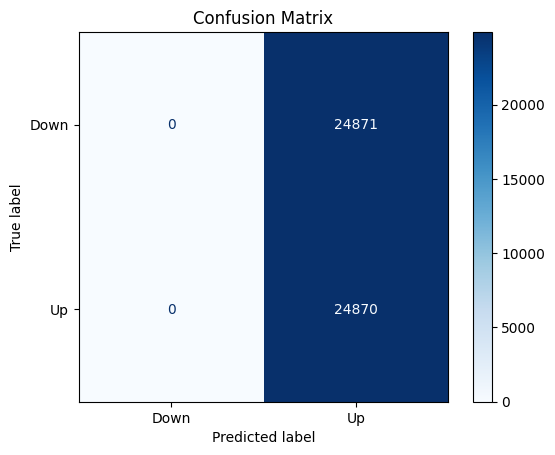

In [8]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

if 'vt' in globals() and 'vpb' in globals():
    cm = confusion_matrix(vt, vpb)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.show()
else:
    print("Validation variables (vt, vpb) not found. Please run the training cell above first.")

## 5. Export

In [11]:
!pip install onnxscript onnxruntime
model.eval()

# Export wrapper to exclude auxiliary head
class InferenceModel(nn.Module):
    def __init__(self, trained_model):
        super().__init__()
        self.model = trained_model
    def forward(self, x):
        direction, _ = self.model(x)
        return direction

infer_model = InferenceModel(model)
infer_model.eval()
dummy = torch.randn(1, 32, 8).to(device)

try:
    # Use opset_version=18 to avoid the 'Pad' adapter error seen in previous execution
    torch.onnx.export(
        infer_model, dummy, "model.onnx",
        export_params=True, opset_version=18, do_constant_folding=True,
        input_names=['input'], output_names=['output']
    )
    print("Model exported to model.onnx (Opset 18)")
except Exception as e:
    print(f"Export failed: {e}")

# Task 14: ONNX Output Validation and Quantization with Pre-processing
import onnxruntime as ort
from onnxruntime.quantization import quantize_dynamic, QuantType, quant_pre_process

if os.path.exists("model.onnx"):
    # Validation
    sess = ort.InferenceSession("model.onnx")
    out = sess.run(None, {'input': dummy.cpu().numpy()})[0]
    print(f"ONNX Model validation successful. Output: {out.item():.4f}")

    # Task 9: INT8 Quantization with Pre-processing to solve ShapeInferenceError
    try:
        # Step 1: Pre-process to clean up shapes and metadata
        preprocessed_path = "model_preprocessed.onnx"
        quant_pre_process("model.onnx", preprocessed_path)

        # Step 2: Quantize the pre-processed model
        quant_path = "model_quantized.onnx"
        quantize_dynamic(preprocessed_path, quant_path, weight_type=QuantType.QUInt8)
        print(f"Dynamic INT8 Quantization Successful: {quant_path}")
    except Exception as e:
        print(f"Quantization failed: {e}")

    # Task 13: Environment-aware Export
    if env == 'colab':
        from google.colab import files
        try:
            files.download("model_quantized.onnx")
        except Exception as download_err:
            print(f"Auto-download skipped: {download_err}")
    elif env == 'kaggle':
        print("Model saved to /kaggle/working/model_quantized.onnx")
    else:
        print("Model saved locally as model_quantized.onnx")
else:
    print("Export file not found. Check the export logs above.")

  Using cached onnxruntime-1.25.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 18.5 MB/s eta 0:00:00
[torch.onnx] Obtain model graph for `InferenceModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `InferenceModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Model exported to model.onnx (Opset 18)
ONNX Model validation successful. Output: 0.5642
Dynamic INT8 Quantization Successful: model_quantized.onnx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>